# Bakery sales demo: predictive workflow with train, validation, and test

This notebook shows a **proper predictive modelling process**:

1. Load and prepare the bakery sales data
2. Aggregate transactions into item-level demand (`quantity`)
3. Create pseudo prices for revenue simulation
4. Split the data into **train**, **validation**, and **test** sets using time
5. Train **multiple candidate models** on the training set only
6. Compare those models on the validation set
7. Choose the best validation model
8. Evaluate that chosen model once on the test set
9. Convert predicted quantity into pseudo revenue scenarios

This is different from a hypothesis-testing notebook.

A hypothesis-testing workflow asks questions like:
- "Is there a significant difference between groups?"

A predictive workflow asks questions like:
- "How well does the model predict unseen future data?"


In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Mixed-effects modelling
import statsmodels.formula.api as smf

# Metrics
from sklearn.metrics import mean_squared_error, r2_score

# Display settings for easier debugging
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Load the bakery data

We keep the raw file unchanged in `df_raw` so debugging is easier later.


In [2]:
# Load the dataset
# Adjust the path if needed, for example:
# df_raw = pd.read_csv("data/bakery_sales_revised.csv")

df_raw = pd.read_csv("demo/bakery_kaggle/bakery_sales_revised.csv")

# Preview the raw data
df_raw.head()


,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,10/30/2016 9:58,morning,weekend
1,2,Scandinavian,10/30/2016 10:05,morning,weekend
2,2,Scandinavian,10/30/2016 10:05,morning,weekend
3,3,Hot chocolate,10/30/2016 10:07,morning,weekend
4,3,Jam,10/30/2016 10:07,morning,weekend


In [3]:
# Basic structural checks
print("Shape of raw data:", df_raw.shape)

print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nData types:")
print(df_raw.dtypes)

print("\nMissing values per column:")
print(df_raw.isna().sum())


Shape of raw data: (20507, 5)

Column names:
['Transaction', 'Item', 'date_time', 'period_day', 'weekday_weekend']

Data types:
Transaction        int64
Item                 str
date_time            str
period_day           str
weekday_weekend      str
dtype: object

Missing values per column:
Transaction        0
Item               0
date_time          0
period_day         0
weekday_weekend    0
dtype: int64


## 2. Parse the datetime column and create useful time features

The raw file contains a `date_time` column.
We convert it into a true datetime field, then derive extra time features.


In [4]:
# Work on a copy to preserve raw data
df = df_raw.copy()

# Convert date_time to pandas datetime
# errors="coerce" prevents crashes if any bad strings appear
df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")

# Create useful derived features
df["date"] = df["date_time"].dt.date
df["hour"] = df["date_time"].dt.hour
df["month"] = df["date_time"].dt.month
df["day_name"] = df["date_time"].dt.day_name()

# Preview the new features
df[["date_time", "date", "hour", "month", "day_name"]].head()


,date_time,date,hour,month,day_name
0,2016-10-30 09:58:00,2016-10-30,9,10,Sunday
1,2016-10-30 10:05:00,2016-10-30,10,10,Sunday
2,2016-10-30 10:05:00,2016-10-30,10,10,Sunday
3,2016-10-30 10:07:00,2016-10-30,10,10,Sunday
4,2016-10-30 10:07:00,2016-10-30,10,10,Sunday


In [5]:
# Check whether datetime parsing worked
print("Invalid or missing date_time values:", df["date_time"].isna().sum())

# Show problematic rows if any exist
df[df["date_time"].isna()].head()


Invalid or missing date_time values: 0


,Transaction,Item,date_time,period_day,weekday_weekend,date,hour,month,day_name


## 3. Aggregate transactions into item-level quantity

The raw bakery dataset is one row per sold item.

For predictive modelling, we create an aggregated table where each row represents:

- date
- item
- period of day
- weekday/weekend

and `quantity` is the number of units sold for that item in that context.


In [6]:
# Aggregate the raw item-level rows into quantity sold
qty_df = (
    df.groupby(["date", "Item", "period_day", "weekday_weekend"])
      .size()
      .reset_index(name="quantity")
)

qty_df.head()


,date,Item,period_day,weekday_weekend,quantity
0,2016-10-30,Basket,morning,weekend,2
1,2016-10-30,Bread,afternoon,weekend,9
2,2016-10-30,Bread,morning,weekend,20
3,2016-10-30,Cake,afternoon,weekend,1
4,2016-10-30,Chicken sand,afternoon,weekend,1


In [7]:
# Inspect the aggregated quantity table
print("Shape of quantity table:", qty_df.shape)
print("Unique items:", qty_df["Item"].nunique())

print("\nQuantity summary:")
print(qty_df["quantity"].describe())

print("\nHighest observed quantities:")
display(qty_df.sort_values("quantity", ascending=False).head(10))


Shape of quantity table: (5627, 5)
Unique items: 94

Quantity summary:
count    5627.000000
mean        3.644393
std         4.603694
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        39.000000
Name: quantity, dtype: float64

Highest observed quantities:


,date,Item,period_day,weekday_weekend,quantity
3172,2017-02-04,Coffee,afternoon,weekend,39
251,2016-11-05,Coffee,morning,weekend,39
4045,2017-02-26,Coffee,afternoon,weekend,37
45,2016-10-31,Coffee,morning,weekday,36
793,2016-11-19,Coffee,morning,weekend,34
5013,2017-03-25,Coffee,afternoon,weekend,32
250,2016-11-05,Coffee,afternoon,weekend,32
2891,2017-01-28,Coffee,morning,weekend,32
3229,2017-02-05,Coffee,afternoon,weekend,32
2191,2017-01-07,Coffee,afternoon,weekend,32


## 4. Create pseudo prices

The dataset does not include true item prices, so we create a pseudo price layer.

This is useful because:
- the demand model predicts quantity
- bakery owners can later adjust price assumptions
- revenue can be simulated without retraining the demand model


In [8]:
# Example pseudo prices for selected items
base_price_map = {
    "Coffee": 2.8,
    "Bread": 3.5,
    "Tea": 2.5,
    "Cake": 4.8,
    "Pastry": 3.8,
    "Sandwich": 5.5,
    "Medialuna": 2.7,
    "Hot chocolate": 3.2,
    "Cookies": 2.4,
    "Brownie": 3.0,
    "Farm House": 4.5,
    "Muffin": 2.9,
    "Alfajores": 2.6,
    "Juice": 3.0,
    "Soup": 4.9,
    "Scone": 2.8,
    "Toast": 3.2,
    "Scandinavian": 3.8,
    "Truffles": 3.4,
    "Coke": 2.2
}

# Fallback price for items not yet listed manually
default_price = 3.5

# Map prices onto items
qty_df["base_price"] = qty_df["Item"].map(base_price_map).fillna(default_price)

# Preview
qty_df[["Item", "base_price"]].drop_duplicates().sort_values("Item").head(20)


,Item,base_price
409,Adjustment,3.5
2163,Afternoon with the baker,3.5
76,Alfajores,2.6
4472,Argentina Night,3.5
370,Art Tray,3.5
571,Bacon,3.5
2785,Baguette,3.5
1017,Bakewell,3.5
1594,Bare Popcorn,3.5
0,Basket,3.5


In [9]:
# Which items still use the fallback price?
missing_price_items = sorted(set(qty_df.loc[~qty_df["Item"].isin(base_price_map), "Item"]))

print("Number of items using the default price:", len(missing_price_items))
print("\nExample items using default price:")
print(missing_price_items[:20])


Number of items using the default price: 74

Example items using default price:
['Adjustment', 'Afternoon with the baker', 'Argentina Night', 'Art Tray', 'Bacon', 'Baguette', 'Bakewell', 'Bare Popcorn', 'Basket', 'Bowl Nic Pitt', 'Bread Pudding', 'Brioche and salami', 'Caramel bites', 'Cherry me Dried fruit', 'Chicken Stew', 'Chicken sand', 'Chimichurri Oil', 'Chocolates', 'Christmas common', 'Coffee granules']


In [10]:
# Build a baseline pseudo-revenue column from observed quantity
qty_df["baseline_revenue"] = qty_df["quantity"] * qty_df["base_price"]

qty_df.head()


,date,Item,period_day,weekday_weekend,quantity,base_price,baseline_revenue
0,2016-10-30,Basket,morning,weekend,2,3.5,7.0
1,2016-10-30,Bread,afternoon,weekend,9,3.5,31.5
2,2016-10-30,Bread,morning,weekend,20,3.5,70.0
3,2016-10-30,Cake,afternoon,weekend,1,4.8,4.8
4,2016-10-30,Chicken sand,afternoon,weekend,1,3.5,3.5


## 5. Prepare modelling data types

We mark the categorical predictors explicitly.
This helps both modelling and debugging.


In [11]:
# Convert columns to useful modelling types
qty_df["Item"] = qty_df["Item"].astype("category")
qty_df["period_day"] = qty_df["period_day"].astype("category")
qty_df["weekday_weekend"] = qty_df["weekday_weekend"].astype("category")

# Convert date to full datetime for sorting and splitting
qty_df["date"] = pd.to_datetime(qty_df["date"])

# Add month as an optional predictor
qty_df["month"] = qty_df["date"].dt.month.astype("category")

qty_df.dtypes


date                datetime64[s]
Item                     category
period_day               category
weekday_weekend          category
quantity                    int64
base_price                float64
baseline_revenue          float64
month                    category
dtype: object

## 6. Exploratory summaries

Before fitting models, it helps to understand the demand distribution.


In [12]:
# Summarise item-level demand behaviour
item_summary = (
    qty_df.groupby("Item", observed=False)["quantity"]
    .agg(["count", "mean", "sum"])
    .sort_values("sum", ascending=False)
)

item_summary.head(15)


,count,mean,sum
Item,,,
Coffee,363,15.071625,5471
Bread,355,9.366197,3325
Tea,339,4.233038,1435
Cake,271,3.782288,1025
Pastry,256,3.343750,856
Sandwich,225,3.426667,771
Medialuna,225,2.737778,616
Hot chocolate,250,2.360000,590
Cookies,246,2.195122,540


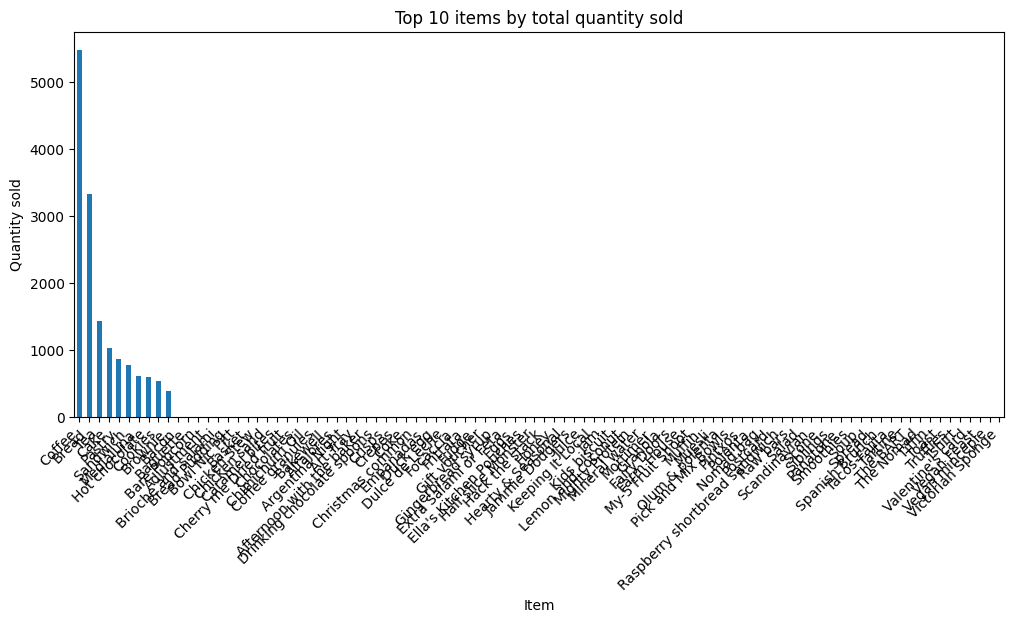

In [13]:
# Plot the top 10 items by total quantity
top_items = item_summary.head(10).index
plot_df = qty_df[qty_df["Item"].isin(top_items)]

plt.figure(figsize=(12, 5))
plot_df.groupby("Item", observed=False)["quantity"].sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Top 10 items by total quantity sold")
plt.ylabel("Quantity sold")
plt.xlabel("Item")
plt.xticks(rotation=45, ha="right")
plt.show()


## 7. Create train, validation, and test sets

This is the key predictive step that was missing from the hypothesis-testing example.

We split the data chronologically:

- **Train**: older data, used to fit candidate models
- **Validation**: later data, used to compare candidate models
- **Test**: newest data, used only once for final scoring

This avoids leakage from future dates into training.


In [14]:
# Sort the modelling table by date
qty_df = qty_df.sort_values("date").reset_index(drop=True)

# Use quantiles of the date distribution to define split points
train_cutoff = qty_df["date"].quantile(0.70)
val_cutoff = qty_df["date"].quantile(0.85)

# Create chronological splits
train_df = qty_df[qty_df["date"] <= train_cutoff].copy()
val_df = qty_df[(qty_df["date"] > train_cutoff) & (qty_df["date"] <= val_cutoff)].copy()
test_df = qty_df[qty_df["date"] > val_cutoff].copy()

# Print split sizes
print("Train size:", train_df.shape)
print("Validation size:", val_df.shape)
print("Test size:", test_df.shape)

# Print the actual date ranges for sanity checking
print("\nTrain date range:", train_df["date"].min(), "→", train_df["date"].max())
print("Validation date range:", val_df["date"].min(), "→", val_df["date"].max())
print("Test date range:", test_df["date"].min(), "→", test_df["date"].max())


Train size: (3947, 8)
Validation size: (850, 8)
Test size: (830, 8)

Train date range: 2016-10-30 00:00:00 → 2017-02-23 00:00:00
Validation date range: 2017-02-24 00:00:00 → 2017-03-18 00:00:00
Test date range: 2017-03-19 00:00:00 → 2017-04-09 00:00:00


## 8. Define candidate models

Now we build **multiple models**.

This is important because the validation set should not be used only for reporting.
It should be used to **compare candidate models and select one**.

Candidate models in this notebook:

- **Model_A**: `quantity ~ period_day + weekday_weekend`
- **Model_B**: `quantity ~ period_day + weekday_weekend + month`
- **Model_C**: `quantity ~ period_day * weekday_weekend`

All models use:
- random intercept by `Item`


In [15]:
# Define candidate mixed-model formulas
candidate_formulas = {
    "Model_A": "quantity ~ period_day + weekday_weekend",
    "Model_B": "quantity ~ period_day + weekday_weekend + month",
    "Model_C": "quantity ~ period_day * weekday_weekend"
}

candidate_formulas


{'Model_A': 'quantity ~ period_day + weekday_weekend',
 'Model_B': 'quantity ~ period_day + weekday_weekend + month',
 'Model_C': 'quantity ~ period_day * weekday_weekend'}

## 9. Train each candidate model on the training set only

This is the **training** stage.

We fit each candidate model using `train_df` only.


In [16]:
# Dictionary to store fitted models
fitted_models = {}

# Train each candidate model on the training set only
for model_name, formula in candidate_formulas.items():
    print(f"Training {model_name} with formula: {formula}")

    model = smf.mixedlm(
        formula,
        data=train_df,
        groups=train_df["Item"]
    )

    # Fit and store the result
    fitted_result = model.fit(method="lbfgs")
    fitted_models[model_name] = fitted_result

    print(f"{model_name} training complete.")
    print("-" * 60)

print("All candidate models trained.")


Training Model_A with formula: quantity ~ period_day + weekday_weekend


/home/xi/miniconda3/envs/pred/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/xi/miniconda3/envs/pred/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/xi/miniconda3/envs/pred/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/xi/miniconda3/envs/pred/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/xi/miniconda3/envs/pred/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values

Model_A training complete.
------------------------------------------------------------
Training Model_B with formula: quantity ~ period_day + weekday_weekend + month


LinAlgError: Singular matrix

## 10. Score each candidate model on the validation set

This is the **validation** stage.

We do **not** refit on validation.
We only use the already-trained models to predict on `val_df`,
then compare their validation performance.


In [ ]:
def score_predictions(y_true, y_pred):
    """Return a small dictionary of scoring metrics."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MSE": mse, "RMSE": rmse, "R2": r2}


In [ ]:
# Score all candidate models on the validation set
validation_rows = []

for model_name, fitted_result in fitted_models.items():
    # Predict on validation data only
    val_pred = fitted_result.predict(val_df).clip(lower=0)

    # Score those validation predictions
    metrics = score_predictions(val_df["quantity"], val_pred)

    validation_rows.append({
        "model_name": model_name,
        "formula": candidate_formulas[model_name],
        "val_MSE": metrics["MSE"],
        "val_RMSE": metrics["RMSE"],
        "val_R2": metrics["R2"]
    })

validation_results = pd.DataFrame(validation_rows).sort_values("val_RMSE").reset_index(drop=True)
validation_results


## 11. Select the best model based on validation performance

Here we choose the model with the **lowest validation RMSE**.

This is the actual model-selection step that turns the notebook into a proper predictive workflow.


In [ ]:
# Select the best model by validation RMSE
best_model_name = validation_results.loc[0, "model_name"]
best_formula = candidate_formulas[best_model_name]
best_model_result = fitted_models[best_model_name]

print("Best model chosen from validation:")
print("Model name:", best_model_name)
print("Formula:", best_formula)


In [ ]:
# Show the validation comparison table clearly
validation_results


## 12. Evaluate the selected model on train, validation, and test

This is where the full predictive process becomes visible:

- train the models on training data
- compare them on validation data
- lock the best model
- score the chosen model on the unseen test data

The **test score** is the honest final performance estimate.


In [ ]:
def evaluate_frame(frame, fitted_result, name):
    """Predict on one dataset, clip negatives, and return metrics plus predictions."""
    preds = fitted_result.predict(frame).clip(lower=0)
    metrics = score_predictions(frame["quantity"], preds)

    print(f"{name} MSE:  {metrics['MSE']:.4f}")
    print(f"{name} RMSE: {metrics['RMSE']:.4f}")
    print(f"{name} R2:   {metrics['R2']:.4f}")
    print("-" * 50)

    return preds, metrics

# Score the chosen model on all three datasets
train_pred_best, train_metrics_best = evaluate_frame(train_df, best_model_result, "TRAIN")
val_pred_best, val_metrics_best = evaluate_frame(val_df, best_model_result, "VALIDATION")
test_pred_best, test_metrics_best = evaluate_frame(test_df, best_model_result, "TEST")


In [ ]:
# Store the chosen-model predictions inside each split
train_df["pred_quantity"] = train_pred_best
val_df["pred_quantity"] = val_pred_best
test_df["pred_quantity"] = test_pred_best

print("Chosen-model predictions stored in train_df, val_df, and test_df.")


In [ ]:
# Build a compact metrics summary table
final_metrics_table = pd.DataFrame([
    {"dataset": "TRAIN", "MSE": train_metrics_best["MSE"], "RMSE": train_metrics_best["RMSE"], "R2": train_metrics_best["R2"]},
    {"dataset": "VALIDATION", "MSE": val_metrics_best["MSE"], "RMSE": val_metrics_best["RMSE"], "R2": val_metrics_best["R2"]},
    {"dataset": "TEST", "MSE": test_metrics_best["MSE"], "RMSE": test_metrics_best["RMSE"], "R2": test_metrics_best["R2"]}
])

final_metrics_table


## 13. Visualise the chosen model on the test set

This plot helps you inspect how the selected model generalises to unseen future data.


In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(test_df["quantity"], test_df["pred_quantity"], alpha=0.3)

plt.xlabel("Observed quantity (test)")
plt.ylabel("Predicted quantity (test)")
plt.title(f"Chosen model on test set: {best_model_name}")

plt.show()


## 14. Create owner-adjustable price scenarios

The selected model predicts demand quantity.
Revenue is then derived by multiplying predicted quantity by prices.

That means owners can change prices without retraining the demand model.


In [ ]:
# Example owner adjustments to the pseudo base prices
# 1.10 means +10%, 0.95 means -5%, and 1.00 means unchanged
owner_price_adjustment = {
    "Coffee": 1.10,
    "Bread": 1.00,
    "Tea": 0.95,
    "Cake": 1.15,
    "Pastry": 1.05
}

# Apply adjusted prices to each split
for frame in [train_df, val_df, test_df]:
    frame["adjusted_price"] = frame.apply(
        lambda row: row["base_price"] * owner_price_adjustment.get(row["Item"], 1.0),
        axis=1
    )


In [ ]:
# Convert predicted quantity into revenue under baseline and adjusted price assumptions
for frame in [train_df, val_df, test_df]:
    frame["pred_revenue_base"] = frame["pred_quantity"] * frame["base_price"]
    frame["pred_revenue_adjusted"] = frame["pred_quantity"] * frame["adjusted_price"]

test_df.head()


## 15. Compare revenue by item on the test set

Using the test set keeps the business view aligned with the final predictive evaluation.


In [ ]:
# Aggregate predicted revenue by item on the test set
test_revenue_compare = (
    test_df.groupby("Item", observed=False)[["pred_revenue_base", "pred_revenue_adjusted"]]
    .sum()
    .sort_values("pred_revenue_base", ascending=False)
)

test_revenue_compare.head(15)


In [ ]:
# Plot the top 10 items by predicted revenue on the test set
top_rev_items = test_revenue_compare.head(10)

top_rev_items.plot(kind="bar", figsize=(12, 5))
plt.title("Test set: top 10 items by baseline vs adjusted predicted revenue")
plt.ylabel("Predicted revenue")
plt.xlabel("Item")
plt.xticks(rotation=45, ha="right")
plt.show()


## 16. Create a daily forecast table from the test set

A daily summary is often easier to show to stakeholders than raw item-level predictions.


In [ ]:
# Aggregate test-set daily revenue
daily_test_forecast = (
    test_df.groupby("date", observed=False)[["pred_revenue_base", "pred_revenue_adjusted"]]
    .sum()
    .reset_index()
    .sort_values("date")
)

daily_test_forecast.head()


In [ ]:
# Plot the daily forecast
plt.figure(figsize=(12, 5))
plt.plot(daily_test_forecast["date"], daily_test_forecast["pred_revenue_base"], label="Baseline")
plt.plot(daily_test_forecast["date"], daily_test_forecast["pred_revenue_adjusted"], label="Adjusted")

plt.title("Test set: daily predicted revenue")
plt.ylabel("Revenue")
plt.xlabel("Date")
plt.legend()
plt.xticks(rotation=45)

plt.show()


## 17. Export outputs

We export:
- train predictions
- validation predictions
- test predictions
- test daily revenue forecast
- validation model comparison table
- final dataset scoring table

This makes the notebook easier to reuse in later demos or dashboards.


In [ ]:
# Export split-level predictions
train_df.to_csv("demo/bakery_kaggle/bakery_train_predictions.csv", index=False)
val_df.to_csv("demo/bakery_kaggle/bakery_validation_predictions.csv", index=False)
test_df.to_csv("demo/bakery_kaggle/bakery_test_predictions.csv", index=False)

# Export forecast and scoring tables
daily_test_forecast.to_csv("demo/bakery_kaggle/bakery_test_daily_revenue_forecast.csv", index=False)
validation_results.to_csv("demo/bakery_kaggle/bakery_validation_model_comparison.csv", index=False)
final_metrics_table.to_csv("demo/bakery_kaggle/bakery_final_metrics_table.csv", index=False)

print("Export complete.")


In [ ]:
# Optional helper: show the current working directory
import os
print("Current working directory:")
print(os.getcwd())
